# Praktikum: Credit Scoring, Alternative Data, dan Machine Learning
### Pertemuan 6 — Mata Kuliah IT in Financial Service (DBT-3204)
**Program Studi Digital Business Technology, School of STEM, Universitas Prasetiya Mulya**

---

**Tujuan Praktikum (Sub-CPMK-6):**
Mahasiswa mampu membangun dan mengevaluasi model credit scoring berbasis data alternatif
secara bertanggung jawab.

**Yang akan dikerjakan pada notebook ini:**
1. Membangun scorecard dengan **WOE (Weight of Evidence) + Logistic Regression**
2. Membandingkan dengan **XGBoost** dan menjelaskan hasil dengan **SHAP**
3. Menguji **bias pada subkelompok demografis** dan menulis rekomendasi mitigasi

**Asesmen:** Model report + refleksi etika (bobot 7% dari nilai akhir mata kuliah).

> Sebelum menjalankan notebook ini, jalankan `python 01_generate_dataset.py` satu kali untuk
> membangkitkan dataset sintetis di folder `data/`.

**Catatan penting:** Dataset pada praktikum ini **sepenuhnya sintetis** — dibuat khusus untuk
latihan ini dan tidak berasal dari data nasabah sungguhan. Satu wilayah dalam dataset
**sengaja diberi bias tersembunyi** agar dapat ditemukan pada Bagian 3. Ini adalah desain
pedagogis, bukan cerminan kondisi nyata di industri.


In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
DATA_DIR = Path("data")
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

df = pd.read_csv(DATA_DIR / "kredit_alternatif.csv")
print(f"Dataset: {df.shape[0]:,} baris, {df.shape[1]} kolom")
df.head()


Dataset: 12,000 baris, 20 kolom


,customer_id,wilayah,kelompok_usia,jenis_kelamin,segmen_pekerjaan,thin_file,lama_riwayat_kredit_bulan,jumlah_fasilitas_kredit_aktif,rasio_utang_pendapatan,riwayat_keterlambatan_90hari,konsistensi_isi_ulang_pulsa,lama_kepemilikan_nomor_bulan,rata_rata_pulsa_bulanan_rp,frekuensi_transaksi_ecommerce_bulanan,rating_rata_penjual_pembeli,rasio_retur_pembelian,rata_rata_kas_masuk_bulanan_rp,volatilitas_kas_cv,jumlah_hari_kas_negatif_per_bulan,default_flag
0,CUST100000,Kalimantan,36-45,P,Pekerja Informal/Gig,0,59.000,8,0.247,0.000,0.908,134.000,"37,000.000",4,3.780,0.073,"810,000.000",0.206,1,0
1,CUST100001,Jawa Non-Jabodetabek,26-35,P,Karyawan Formal,0,66.000,1,0.670,0.000,0.808,35.000,"72,000.000",4,3.930,0.097,"1,950,000.000",0.183,0,0
2,CUST100002,Sulawesi,18-25,L,UMKM/Wirausaha,1,0.000,0,0.152,NaN,0.661,134.000,"57,000.000",2,4.240,0.020,"1,410,000.000",0.239,3,0
3,CUST100003,Kalimantan,56+,L,Karyawan Formal,0,32.000,0,0.381,0.000,0.862,60.000,"16,000.000",3,4.170,0.031,"3,220,000.000",0.271,1,0
4,CUST100004,Jabodetabek,18-25,L,UMKM/Wirausaha,0,32.000,2,0.150,0.000,0.412,80.000,"27,000.000",3,4.020,0.075,"1,780,000.000",0.272,0,0


## Bagian 0 — Eksplorasi Dataset

Dataset berisi tiga kelompok fitur:
- **Tradisional (mirip SLIK OJK):** `lama_riwayat_kredit_bulan`, `jumlah_fasilitas_kredit_aktif`,
  `rasio_utang_pendapatan`, `riwayat_keterlambatan_90hari`, `thin_file`
- **Alternatif — telko:** `konsistensi_isi_ulang_pulsa`, `lama_kepemilikan_nomor_bulan`,
  `rata_rata_pulsa_bulanan_rp`
- **Alternatif — e-commerce:** `frekuensi_transaksi_ecommerce_bulanan`, `rating_rata_penjual_pembeli`,
  `rasio_retur_pembelian`
- **Alternatif — cashflow UMKM:** `rata_rata_kas_masuk_bulanan_rp`, `volatilitas_kas_cv`,
  `jumlah_hari_kas_negatif_per_bulan`

Target: `default_flag` (1 = gagal bayar dalam 90 hari, setara indikator NPL).

Kolom demografis (`wilayah`, `kelompok_usia`, `jenis_kelamin`) **TIDAK** dimasukkan sebagai
fitur model — hanya dipakai untuk uji bias di Bagian 3.


In [2]:
print("Proporsi thin-file (tanpa riwayat kredit formal):", f"{df['thin_file'].mean():.1%}")
print("Tingkat default keseluruhan:", f"{df['default_flag'].mean():.1%}")
df.groupby("segmen_pekerjaan")["default_flag"].agg(["mean", "count"]).round(3)


Proporsi thin-file (tanpa riwayat kredit formal): 46.7%
Tingkat default keseluruhan: 27.1%


,mean,count
segmen_pekerjaan,,
Karyawan Formal,0.181,4152
Pekerja Informal/Gig,0.242,3660
UMKM/Wirausaha,0.385,4188


In [3]:
import plotly.express as px

fig = px.histogram(df, x="rasio_utang_pendapatan", color="default_flag", barmode="overlay",
                    nbins=40, title="Distribusi Rasio Utang-Pendapatan menurut Status Default",
                    labels={"default_flag": "Default"}, opacity=0.7)
fig.show()


## Bagian 1 — Membangun Scorecard WOE + Logistic Regression

**Alur kerja:**
1. Pilih fitur numerik (tradisional + alternatif)
2. **Binning**: kelompokkan setiap fitur ke dalam 5 kelas (quantile-based)
3. Hitung **WOE (Weight of Evidence)** dan **IV (Information Value)** per fitur
4. Transformasikan fitur asli menjadi nilai WOE
5. Latih **Logistic Regression** pada fitur WOE → scorecard yang mudah diinterpretasikan

WOE dihitung sebagai:

\[ WOE_i = \ln\left(\frac{\%\, \text{Good}_i}{\%\, \text{Bad}_i}\right) \]

IV per fitur adalah jumlah tertimbang WOE di seluruh bin — semakin besar IV, semakin kuat
daya prediktif fitur tersebut terhadap `default_flag`.


In [4]:
FITUR_NUMERIK = [
    "lama_riwayat_kredit_bulan", "jumlah_fasilitas_kredit_aktif", "rasio_utang_pendapatan",
    "konsistensi_isi_ulang_pulsa", "lama_kepemilikan_nomor_bulan", "rata_rata_pulsa_bulanan_rp",
    "frekuensi_transaksi_ecommerce_bulanan", "rating_rata_penjual_pembeli", "rasio_retur_pembelian",
    "rata_rata_kas_masuk_bulanan_rp", "volatilitas_kas_cv", "jumlah_hari_kas_negatif_per_bulan",
]

model_df = df.copy()
model_df["riwayat_keterlambatan_90hari"] = model_df["riwayat_keterlambatan_90hari"].fillna(
    model_df["riwayat_keterlambatan_90hari"].median()
)
FITUR_NUMERIK.append("riwayat_keterlambatan_90hari")

print(f"Total fitur untuk scorecard: {len(FITUR_NUMERIK)}")


Total fitur untuk scorecard: 13


In [5]:
def hitung_woe_iv(series, target, n_bins=5):
    """Bin fitur numerik ke n_bins kuantil, hitung WOE dan IV per bin."""
    binned = pd.qcut(series, q=n_bins, duplicates="drop")
    tab = pd.DataFrame({"bin": binned, "target": target})
    grp = tab.groupby("bin")["target"].agg(["count", "sum"])
    grp.columns = ["total", "bad"]
    grp["good"] = grp["total"] - grp["bad"]
    total_good, total_bad = grp["good"].sum(), grp["bad"].sum()
    grp["pct_good"] = grp["good"].clip(lower=0.5) / total_good
    grp["pct_bad"] = grp["bad"].clip(lower=0.5) / total_bad
    grp["woe"] = np.log(grp["pct_good"] / grp["pct_bad"])
    grp["iv"] = (grp["pct_good"] - grp["pct_bad"]) * grp["woe"]
    return grp, grp["iv"].sum()

iv_table = []
woe_maps = {}
for f in FITUR_NUMERIK:
    grp, iv = hitung_woe_iv(model_df[f], model_df["default_flag"])
    woe_maps[f] = grp["woe"]
    iv_table.append({"fitur": f, "information_value": round(iv, 4)})

iv_df = pd.DataFrame(iv_table).sort_values("information_value", ascending=False).reset_index(drop=True)
iv_df["kekuatan_prediktif"] = pd.cut(
    iv_df["information_value"], bins=[-1, 0.02, 0.1, 0.3, 10],
    labels=["Lemah", "Sedang", "Kuat", "Sangat Kuat / Curigai Overfit"]
)
iv_df


,fitur,information_value,kekuatan_prediktif
0,rasio_utang_pendapatan,0.292,Kuat
1,volatilitas_kas_cv,0.242,Kuat
2,jumlah_hari_kas_negatif_per_bulan,0.138,Kuat
3,konsistensi_isi_ulang_pulsa,0.108,Kuat
4,rating_rata_penjual_pembeli,0.088,Sedang
5,lama_riwayat_kredit_bulan,0.079,Sedang
6,rata_rata_kas_masuk_bulanan_rp,0.043,Sedang
7,jumlah_fasilitas_kredit_aktif,0.034,Sedang
8,rasio_retur_pembelian,0.010,Lemah
9,frekuensi_transaksi_ecommerce_bulanan,0.002,Lemah


**Interpretasi IV** (aturan umum industri credit scoring):
- IV < 0.02 → fitur hampir tidak berguna
- 0.02–0.1 → daya prediktif lemah
- 0.1–0.3 → daya prediktif sedang-kuat, cocok untuk scorecard
- \> 0.3 → sangat kuat, tapi periksa kemungkinan data leakage

Perhatikan fitur mana dari kelompok **tradisional** vs **alternatif** yang memiliki IV
tertinggi — ini akan menjadi bahan diskusi laporan Anda.


In [6]:
def terapkan_woe(series, grp, n_bins=5):
    binned = pd.qcut(series, q=n_bins, duplicates="drop")
    return binned.map(grp["woe"]).astype(float)

X_woe = pd.DataFrame({f: terapkan_woe(model_df[f], hitung_woe_iv(model_df[f], model_df["default_flag"])[0])
                       for f in FITUR_NUMERIK})
y = model_df["default_flag"]

X_woe.head()


,lama_riwayat_kredit_bulan,jumlah_fasilitas_kredit_aktif,rasio_utang_pendapatan,konsistensi_isi_ulang_pulsa,lama_kepemilikan_nomor_bulan,rata_rata_pulsa_bulanan_rp,frekuensi_transaksi_ecommerce_bulanan,rating_rata_penjual_pembeli,rasio_retur_pembelian,rata_rata_kas_masuk_bulanan_rp,volatilitas_kas_cv,jumlah_hari_kas_negatif_per_bulan,riwayat_keterlambatan_90hari
0,0.457,0.324,0.449,0.440,0.050,-0.027,0.064,-0.446,-0.027,0.264,0.409,0.317,0.000
1,0.457,-0.103,-0.751,0.286,0.015,0.011,0.064,-0.446,0.054,0.134,0.409,0.317,0.000
2,-0.210,-0.103,0.855,0.038,0.050,-0.049,0.011,-0.145,0.108,0.264,0.114,-0.333,0.000
3,0.273,-0.103,0.012,0.440,-0.000,0.042,0.011,-0.145,0.048,-0.082,0.114,0.317,0.000
4,0.273,0.345,0.855,-0.492,-0.011,0.019,0.011,-0.145,-0.027,0.134,0.114,0.317,0.000


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

X_train, X_test, y_train, y_test = train_test_split(
    X_woe, y, test_size=0.25, random_state=42, stratify=y
)

scorecard_model = LogisticRegression(max_iter=1000)
scorecard_model.fit(X_train, y_train)

proba_scorecard = scorecard_model.predict_proba(X_test)[:, 1]
auc_scorecard = roc_auc_score(y_test, proba_scorecard)
print(f"AUC-ROC Scorecard (WOE + Logistic Regression): {auc_scorecard:.4f}")

coef_df = pd.DataFrame({
    "fitur": FITUR_NUMERIK, "koefisien": scorecard_model.coef_[0]
}).sort_values("koefisien", key=abs, ascending=False)
coef_df


AUC-ROC Scorecard (WOE + Logistic Regression): 0.7468


,fitur,koefisien
6,frekuensi_transaksi_ecommerce_bulanan,-1.209
2,rasio_utang_pendapatan,-1.185
3,konsistensi_isi_ulang_pulsa,-1.124
8,rasio_retur_pembelian,-1.112
7,rating_rata_penjual_pembeli,-1.031
0,lama_riwayat_kredit_bulan,-0.936
10,volatilitas_kas_cv,-0.883
4,lama_kepemilikan_nomor_bulan,-0.849
11,jumlah_hari_kas_negatif_per_bulan,-0.599
5,rata_rata_pulsa_bulanan_rp,-0.508


**Membaca koefisien scorecard:** karena fitur sudah dalam skala WOE, koefisien positif berarti
bin dengan WOE tinggi (proporsi nasabah baik lebih besar) menurunkan skor risiko — sebaliknya,
koefisien negatif berarti WOE tinggi justru menaikkan risiko pada model ini. Diskusikan apakah
arah setiap koefisien **masuk akal secara bisnis** sebelum melanjutkan.


## Bagian 2 — Membandingkan dengan XGBoost dan Menjelaskan dengan SHAP

Scorecard WOE mudah diaudit tapi mengasumsikan hubungan linear per-bin. **Gradient boosting**
(XGBoost) dapat menangkap interaksi non-linear antar fitur, biasanya dengan akurasi lebih
tinggi — namun jauh lebih sulit dijelaskan tanpa alat tambahan.

**SHAP (SHapley Additive exPlanations)** mengadaptasi konsep teori permainan untuk mengukur
kontribusi adil setiap fitur terhadap satu prediksi, sekaligus memberi ringkasan global fitur
paling berpengaruh di seluruh populasi.


In [8]:
from xgboost import XGBClassifier

X_raw = model_df[FITUR_NUMERIK]
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y, test_size=0.25, random_state=42, stratify=y
)

xgb_model = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9, eval_metric="auc", random_state=42
)
xgb_model.fit(X_train_raw, y_train_raw)

proba_xgb = xgb_model.predict_proba(X_test_raw)[:, 1]
auc_xgb = roc_auc_score(y_test_raw, proba_xgb)
print(f"AUC-ROC XGBoost: {auc_xgb:.4f}")
print(f"AUC-ROC Scorecard WOE: {auc_scorecard:.4f}")
print(f"Selisih AUC: {auc_xgb - auc_scorecard:+.4f}")


AUC-ROC XGBoost: 0.7594
AUC-ROC Scorecard WOE: 0.7468
Selisih AUC: +0.0125


In [9]:
def hitung_ks_gini(y_true, y_proba):
    """Menghitung KS statistic dan koefisien Gini dari AUC-ROC."""
    from sklearn.metrics import roc_curve
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    ks = np.max(np.abs(tpr - fpr))
    auc = roc_auc_score(y_true, y_proba)
    gini = 2 * auc - 1
    return ks, gini

ks_score, gini_score = hitung_ks_gini(y_test, proba_scorecard)
ks_xgb, gini_xgb = hitung_ks_gini(y_test_raw, proba_xgb)

pd.DataFrame({
    "Model": ["Scorecard WOE + Logistic", "XGBoost"],
    "AUC-ROC": [auc_scorecard, auc_xgb],
    "KS Statistic": [ks_score, ks_xgb],
    "Gini": [gini_score, gini_xgb],
}).round(4)


,Model,AUC-ROC,KS Statistic,Gini
0,Scorecard WOE + Logistic,0.747,0.372,0.494
1,XGBoost,0.759,0.399,0.519


**Trade-off akurasi vs interpretabilitas:** catat selisih AUC/Gini antara kedua model di
laporan Anda. Jika selisihnya kecil, scorecard yang jauh lebih mudah diaudit mungkin lebih
disukai regulator dan tim risiko — ini adalah keputusan bisnis, bukan murni teknis.


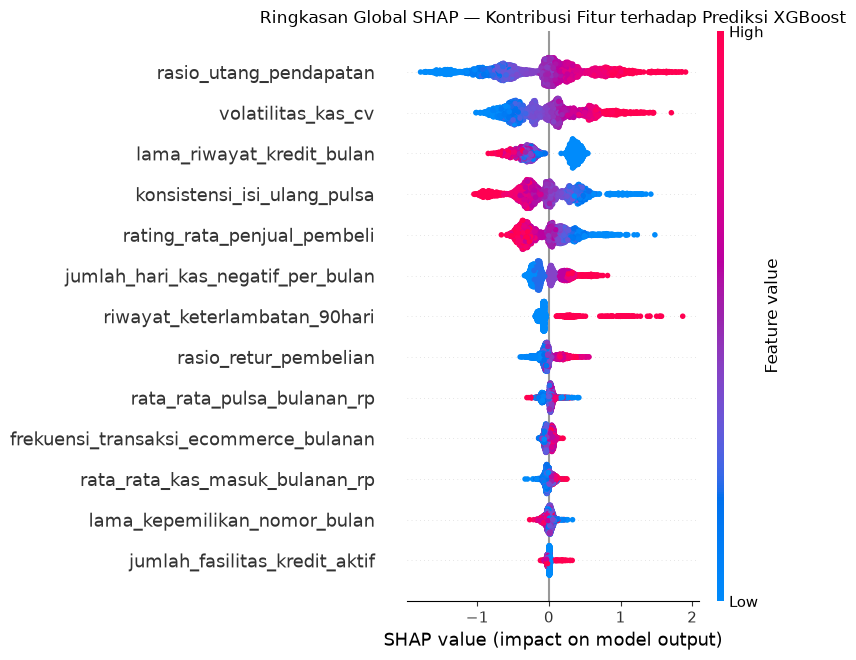

In [10]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_raw)

shap.summary_plot(shap_values, X_test_raw, show=False)
import matplotlib.pyplot as plt
plt.title("Ringkasan Global SHAP — Kontribusi Fitur terhadap Prediksi XGBoost")
plt.tight_layout()
plt.savefig("output/shap_summary.png", dpi=120, bbox_inches="tight")
plt.show()


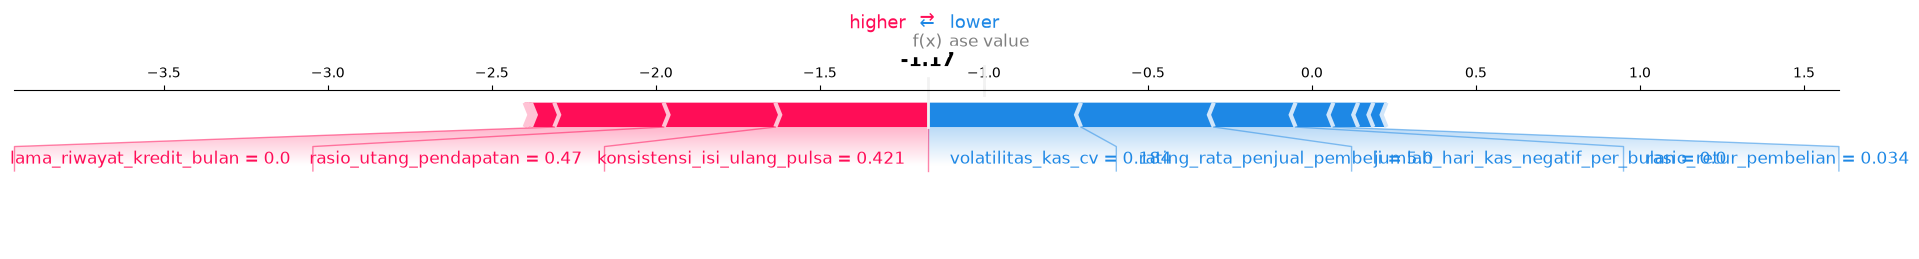

Prediksi probabilitas default nasabah ini: 23.66%

Tiga fitur paling berpengaruh untuk nasabah ini:


volatilitas_kas_cv            -0.468
konsistensi_isi_ulang_pulsa    0.464
rating_rata_penjual_pembeli   -0.405
dtype: float32

In [11]:
# Penjelasan untuk satu nasabah individual (baris pertama data uji)
idx = 0
shap.force_plot(
    explainer.expected_value, shap_values[idx], X_test_raw.iloc[idx],
    matplotlib=True, show=False
)
plt.tight_layout()
plt.savefig("output/shap_force_individu.png", dpi=120, bbox_inches="tight")
plt.show()

print("Prediksi probabilitas default nasabah ini:", f"{proba_xgb[idx]:.2%}")
print("\nTiga fitur paling berpengaruh untuk nasabah ini:")
contrib = pd.Series(shap_values[idx], index=FITUR_NUMERIK).sort_values(key=abs, ascending=False)
contrib.head(3)


**Tugas refleksi:** identifikasi tiga fitur paling berpengaruh secara global (dari summary
plot) dan bandingkan dengan tiga fitur ber-IV tertinggi pada scorecard di Bagian 1 — apakah
kedua model "melihat" hal yang mirip atau berbeda?


## Bagian 3 — Uji Bias pada Subkelompok Demografis

Model yang akurat secara statistik tetap bisa **tidak adil** bila menghasilkan tingkat
persetujuan yang berbeda-beda secara sistematis antar kelompok demografis — inilah yang
disebut **disparate impact**. Kolom demografis (`wilayah`, `kelompok_usia`, `jenis_kelamin`)
sengaja **tidak** dipakai sebagai fitur model, tapi bias bisa tetap muncul lewat **proxy
discrimination** — variabel lain yang secara tidak langsung berkorelasi dengan demografi.

Kita akan memeriksa: apakah tingkat prediksi risiko (dan keputusan approval) berbeda secara
tidak wajar antar wilayah, walau wilayah tidak pernah dimasukkan ke model?


In [12]:
hasil_uji = model_df.loc[X_test_raw.index].copy()
hasil_uji["proba_default_xgb"] = proba_xgb
hasil_uji["proba_default_scorecard"] = proba_scorecard

AMBANG_APPROVAL = 0.30  # nasabah disetujui bila prediksi risiko default < 30%
hasil_uji["approved_xgb"] = (hasil_uji["proba_default_xgb"] < AMBANG_APPROVAL).astype(int)

ringkasan_wilayah = hasil_uji.groupby("wilayah").agg(
    jumlah_nasabah=("customer_id", "count"),
    rata_rata_prediksi_risiko=("proba_default_xgb", "mean"),
    tingkat_approval=("approved_xgb", "mean"),
    tingkat_default_aktual=("default_flag", "mean"),
).round(3).sort_values("tingkat_approval")

ringkasan_wilayah


,jumlah_nasabah,rata_rata_prediksi_risiko,tingkat_approval,tingkat_default_aktual
wilayah,,,,
Luar Jawa Lainnya,269,0.300,0.606,0.558
Jabodetabek,850,0.270,0.647,0.232
Kalimantan,363,0.269,0.653,0.287
Sulawesi,295,0.263,0.675,0.203
Jawa Non-Jabodetabek,649,0.246,0.687,0.253
Sumatra,574,0.254,0.702,0.239


In [13]:
fig = px.bar(
    ringkasan_wilayah.reset_index(), x="wilayah", y="tingkat_approval",
    title="Tingkat Approval Model XGBoost per Wilayah (ambang risiko 30%)",
    labels={"tingkat_approval": "Tingkat Approval", "wilayah": "Wilayah"},
    color="tingkat_approval", color_continuous_scale="RdYlGn",
)
fig.add_hline(y=hasil_uji["approved_xgb"].mean(), line_dash="dash",
              annotation_text="Rata-rata keseluruhan")
fig.show()


**Aturan praktis disparate impact (adverse impact ratio / "four-fifths rule"):** bila
tingkat approval kelompok tertentu kurang dari **80%** tingkat approval kelompok dengan
approval tertinggi, ini dianggap indikasi awal disparate impact yang memerlukan investigasi
lebih lanjut. Kita terapkan aturan ini pada wilayah dan pada tiga atribut demografis lain
sekaligus, supaya perbandingan lebih lengkap.


In [14]:
def tabel_adverse_impact(df_uji, kolom):
    ring = df_uji.groupby(kolom)["approved_xgb"].mean().round(3)
    rasio = (ring / ring.max()).round(3)
    out = pd.DataFrame({"tingkat_approval": ring, "rasio_terhadap_tertinggi": rasio})
    out["indikasi_disparate_impact"] = out["rasio_terhadap_tertinggi"] < 0.8
    return out.sort_values("rasio_terhadap_tertinggi")

tabel_wilayah_ai = tabel_adverse_impact(hasil_uji, "wilayah")
print("--- Adverse impact ratio per wilayah ---")
tabel_wilayah_ai


--- Adverse impact ratio per wilayah ---


,tingkat_approval,rasio_terhadap_tertinggi,indikasi_disparate_impact
wilayah,,,
Luar Jawa Lainnya,0.606,0.863,False
Jabodetabek,0.647,0.922,False
Kalimantan,0.653,0.930,False
Sulawesi,0.675,0.962,False
Jawa Non-Jabodetabek,0.687,0.979,False
Sumatra,0.702,1.000,False


In [15]:
# Uji yang sama untuk kelompok usia, jenis kelamin, dan segmen pekerjaan
hasil_semua = {}
for kolom in ["kelompok_usia", "jenis_kelamin", "segmen_pekerjaan"]:
    tabel = tabel_adverse_impact(hasil_uji, kolom)
    hasil_semua[kolom] = tabel
    print(f"\n--- Adverse impact ratio per {kolom} ---")
    print(tabel)



--- Adverse impact ratio per kelompok_usia ---
               tingkat_approval  rasio_terhadap_tertinggi  \
kelompok_usia                                               
56+                       0.646                     0.958   
36-45                     0.661                     0.981   
46-55                     0.667                     0.990   
18-25                     0.667                     0.990   
26-35                     0.674                     1.000   

               indikasi_disparate_impact  
kelompok_usia                             
56+                                False  
36-45                              False  
46-55                              False  
18-25                              False  
26-35                              False  

--- Adverse impact ratio per jenis_kelamin ---
               tingkat_approval  rasio_terhadap_tertinggi  \
jenis_kelamin                                               
L                         0.665                     0

**Membaca hasil:** `segmen_pekerjaan` biasanya menunjukkan sinyal disparate impact yang
paling jelas (rasio jauh di bawah 0,8) karena volatilitas cashflow UMKM secara sah berkorelasi
dengan risiko — namun ini juga berarti UMKM/Wirausaha secara sistematis lebih sering ditolak,
sehingga tetap layak diperiksa dari sisi keadilan inklusi keuangan. `wilayah` mungkin berada
di sekitar ambang 0,8 — ini adalah kasus "abu-abu" yang realistis: bukan pelanggaran yang
jelas, tapi cukup dekat dengan ambang untuk dilaporkan dan dipantau, terutama karena salah
satu fitur (`konsistensi_isi_ulang_pulsa`) memang berkorelasi dengan wilayah tersebut —
contoh nyata potensi proxy discrimination yang perlu diinvestigasi lebih lanjut, bukan
langsung disimpulkan sebagai bias, maupun langsung diabaikan.


## Rangkuman Temuan & Refleksi Etika (isi setelah menjalankan seluruh notebook)

Isi bagian ini sebagai draf awal laporan model Anda. Jawab dengan singkat dan berbasis angka
dari notebook di atas:

1. **Perbandingan model:** Model mana yang lebih akurat (AUC-ROC/Gini)? Seberapa besar
   selisihnya dibanding kemudahan interpretasi yang hilang?
2. **Fitur paling berpengaruh:** Sebutkan 3 fitur teratas dari IV (Bagian 1) dan dari SHAP
   (Bagian 2) — apakah didominasi data tradisional atau data alternatif?
3. **Temuan bias:** Wilayah/kelompok mana yang menunjukkan indikasi disparate impact? Apakah
   hal ini bisa dijelaskan oleh fitur yang sah, atau kemungkinan proxy discrimination?
4. **Rekomendasi mitigasi:** Usulkan minimal satu langkah konkret (contoh: kalibrasi ulang
   ambang approval per kelompok, menghapus fitur proxy, audit berkala oleh tim independen)
   sebelum model ini layak digunakan untuk keputusan kredit nyata.
5. **Kaitan regulasi:** Bagaimana temuan ini relevan dengan kewajiban akuntabilitas
   penyelenggara Pemeringkat Kredit Alternatif menurut POJK 29/2024?

---
**Referensi:**
- [OJK — POJK 29/2024 tentang Pemeringkat Kredit Alternatif (PKA)](https://ojk.go.id/id/regulasi/Pages/POJK-29-2024-Pemeringkat-Kredit-Alternatif-PKA.aspx)
- [OJK — Sistem Layanan Informasi Keuangan (SLIK)](https://ojk.go.id/id/kanal/perbankan/Pages/Sistem-Layanan-Informasi-Keuangan-SLIK.aspx)
- [MDPI — Explaining Deep Learning Models for Credit Scoring with SHAP](https://www.mdpi.com/1911-8074/16/4/221)
